# Sudoku Solver Project (Mathematics + Python)

**Final Project – Mathematics & Python**

**Author:** *Hristina Todorova*  
**Course:** *Math Concepts for Developers*  
**Date:** 30 March 2026

## Abstract

In this project, I explore Sudoku as a mathematical and algorithmic problem. The notebook models Sudoku as a **constraint satisfaction problem (CSP)** and investigates how different solving strategies behave in practice.

Three components are implemented in Python:
- a validity-checking framework,
- a naive recursive **backtracking** solver,
- an improved solver that uses the **minimum remaining values (MRV)** heuristic and simple **constraint propagation**.

The project combines maths, designing algorithms, and testing them out. The experiments compare the methods on puzzles of different difficulty and evaluate them based on how long they take, the number of recursive calls, and the number of assignments.

The results show that while naive backtracking is enough for simple puzzles, heuristics and constraint propagation can make the search much easier on harder instances. The project shows how maths can be used to turn a fun puzzle into a proper study of algorithms.

## 1. Introduction

I chose Sudoku because I used to solve it in my free time and always wondered whether there was a proper, systematic way to crack even the hardest puzzles — not just guessing and hoping for the best. When I encountered constraint satisfaction problems in this course, I realised that what I had been doing intuitively actually had a precise mathematical structure behind it. That connection motivated me to build a solver from scratch and measure how much smarter algorithms can help.

A standard Sudoku puzzle consists of a $9 \times 9$ grid partially filled with digits from 1 to 9. The goal is to complete the grid so that:
- each row contains every digit from 1 to 9 exactly once,
- each column contains every digit from 1 to 9 exactly once,
- each $3 \times 3$ subgrid contains every digit from 1 to 9 exactly once.

Although Sudoku is often viewed as entertainment, it can also be studied mathematically and algorithmically. It is a natural example of a **constraint satisfaction problem**, where variables must be assigned values that satisfy a set of restrictions.

This project treats Sudoku as a bridge between:
- discrete mathematics,
- combinatorics,
- algorithm design,
- computational experimentation.

The goal is not only to solve Sudoku, but to understand **why some methods are better than others**, and how mathematical structure helps reduce computational complexity.

## 2. Research Question

The main research question of this project is:

**How can Sudoku be modeled as a mathematical constraint satisfaction problem, and how much can heuristics and constraint propagation improve solving performance compared to naive backtracking?**

This question is relevant because Sudoku is simple to state but potentially expensive to solve by brute force. The project therefore investigates not just correctness, but also efficiency and algorithmic design.

## 3. Mathematical Formulation of Sudoku

### 3.1 Variables and domains

Let the Sudoku grid be represented by variables

$$
X_{r,c}, \quad r,c \in \{1,\dots,9\},
$$

where each variable corresponds to one cell in the grid.

Each variable takes values from the domain

$$
D_{r,c} \subseteq \{1,2,3,4,5,6,7,8,9\}.
$$

If a cell is already filled in the initial puzzle, then its domain contains exactly one value. Otherwise, its domain initially contains all values from 1 to 9 that are not ruled out by the constraints.

### 3.2 Constraints

A valid Sudoku solution must satisfy three families of constraints:

1. **Row constraints**  
   For each row, the digits 1–9 must appear exactly once.

2. **Column constraints**  
   For each column, the digits 1–9 must appear exactly once.

3. **Subgrid constraints**  
   For each $3 \times 3$ subgrid, the digits 1–9 must appear exactly once.

This makes Sudoku a **finite constraint satisfaction problem**.

### 3.3 Search space

A brute-force approach wouldn't work because there are too many possible completions. The number of empty cells makes the number of possible completions grow exponentially. The point of an efficient solver is to quickly narrow down the search options.

### 3.4 Constraint propagation intuition

Constraint propagation reduces the number of unassigned cells by getting rid of values that don't follow the existing assignments. In practice, this means finding the best possible values for empty cells and focusing the search on the parts of the board that are most difficult.

In [1]:
import time
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

## 4. Mathematical Insight

We can think of Sudoku as a puzzle where we have to meet certain requirements. Each piece of information in the puzzle can only have a certain number of possible values, and these values must fit within a set of rules.
The more empty cells there are, the harder Sudoku becomes. This makes it hard to solve using a basic search method.
Heuristics (e.g. Minimum Remaining Values (MRV)) reduce the number of branches in the search tree, while constraint propagation reduces the number of possible values for the variables. This shows how maths can make algorithms much better.

## 5. Data Representation and Utility Functions

The Sudoku board (grid) is represented as a list of lists of integers.  
The value `0` denotes an empty cell.

In [2]:
EASY_PUZZLE = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

MEDIUM_PUZZLE = [
    [0, 2, 0, 6, 0, 8, 0, 0, 0],
    [5, 8, 0, 0, 0, 9, 7, 0, 0],
    [0, 0, 0, 0, 4, 0, 0, 0, 0],
    [3, 7, 0, 0, 0, 0, 5, 0, 0],
    [6, 0, 0, 0, 0, 0, 0, 0, 4],
    [0, 0, 8, 0, 0, 0, 0, 1, 3],
    [0, 0, 0, 0, 2, 0, 0, 0, 0],
    [0, 0, 9, 8, 0, 0, 0, 3, 6],
    [0, 0, 0, 3, 0, 6, 0, 9, 0],
]

HARD_PUZZLE = [
    [0, 0, 0, 0, 0, 0, 0, 1, 2],
    [0, 0, 0, 0, 3, 5, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 5, 0, 0, 4, 0, 7],
    [0, 0, 4, 0, 0, 0, 2, 0, 0],
    [9, 0, 7, 0, 0, 2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 8, 0, 0],
    [0, 0, 0, 7, 6, 0, 0, 0, 0],
    [6, 3, 0, 0, 0, 0, 0, 0, 0],
]

PUZZLES = {"Easy": EASY_PUZZLE, "Medium": MEDIUM_PUZZLE, "Hard": HARD_PUZZLE}

In [ ]:
# print the Sudoku grid in a readable format
def print_grid(grid):
    for i, row in enumerate(grid):
        # add a visual separator every 3 rows to show the 3x3 blocks
        if i % 3 == 0 and i != 0:
            print("-" * 21)
        line = []
        for j, val in enumerate(row):
            # add a vertical separator every 3 columns
            if j % 3 == 0 and j != 0:
                line.append("|")
            # empty cells show as '.' so the grid is easier to read
            line.append(str(val) if val != 0 else ".")
        print(" ".join(line))

# convert board to pandas DataFrame for nicer display
def grid_dataframe(grid):
    df = pd.DataFrame(grid, columns=[f"C{j+1}" for j in range(9)])
    df.index = [f"R{i+1}" for i in range(9)]
    return df

# check if placing 'num' at (row, col) would break any constraint
def is_valid(grid, row, col, num):

    # the same number can't appear twice in the same row
    if any(grid[row][j] == num for j in range(9)):
        return False
    
    # the same number can't appear twice in the same column
    if any(grid[i][col] == num for i in range(9)):
        return False
    
    # the same number can't appear twice in the 3x3 box
    box_row = (row // 3) * 3
    box_col = (col // 3) * 3

    for i in range(box_row, box_row + 3):
        for j in range(box_col, box_col + 3):
            if grid[i][j] == num:
                return False
    return True

# scan the grid top-left to bottom-right and return the first empty cell (value = 0)
def find_empty_cell(grid):
    for i in range(9):
        for j in range(9):
            if grid[i][j] == 0:
                return i, j
    return None  # no empty cells → puzzle is fully filled

# the puzzle is complete when there are no empty cells left
def is_complete(grid):
    return find_empty_cell(grid) is None

In [4]:
print("Example: Easy puzzle")
print_grid(EASY_PUZZLE)

Example: Easy puzzle
5 3 . | . 7 . | . . .
6 . . | 1 9 5 | . . .
. 9 8 | . . . | . 6 .
---------------------
8 . . | . 6 . | . . 3
4 . . | 8 . 3 | . . 1
7 . . | . 2 . | . . 6
---------------------
. 6 . | . . . | 2 8 .
. . . | 4 1 9 | . . 5
. . . | . 8 . | . 7 9


## 6. Method 1: Naive Backtracking

Backtracking is the classical recursive method for solving Sudoku.

The idea is:
1. Find the next empty cell.
2. Try digits 1 through 9.
3. Keep a digit if it is valid.
4. Recurse.
5. If a contradiction is reached, undo the assignment and try another value.

This guarantees correctness, but can be expensive because it may explore a large search tree.

In [5]:
class SolverStats:
    def __init__(self):
        self.recursive_calls = 0
        self.assignments = 0
        self.backtracks = 0
        self.propagations = 0

# recursive backtracking solver
def solve_backtracking(grid, stats=None):
    if stats is None:
        stats = SolverStats()

    # count recursive calls
    stats.recursive_calls += 1

    # find next empty cell
    empty = find_empty_cell(grid)

    # if no empty cell → solution found
    if empty is None:
        return True, grid, stats

    row, col = empty

    # try all numbers from 1 to 9
    for num in range(1, 10):

        # check if number is valid
        if is_valid(grid, row, col, num):
            
            # assign number
            grid[row][col] = num
            stats.assignments += 1

            # recursive call
            solved, solved_grid, stats = solve_backtracking(grid, stats)

            if solved:
                return True, solved_grid, stats

            # undo assignment (backtrack)
            grid[row][col] = 0
            stats.backtracks += 1

    # no valid number found → backtrack
    return False, grid, stats

## 7. Method 2: Candidates and Constraint Propagation

Instead of guessing right away, a solver can first calculate the possible answers for each empty cell.  
If a cell has only one candidate, the value is forced and can be assigned immediately.

This is a simple but useful form of **constraint propagation**.

In [6]:
# get all possible values for a cell
def get_candidates(grid, row, col):
    
    # if already filled → no candidates
    if grid[row][col] != 0:
        return set()
    
    # start with all numbers
    candidates = set(range(1, 10))
    
    # remove numbers already in row
    candidates -= set(grid[row][j] for j in range(9))

    # remove numbers already in column
    candidates -= set(grid[i][col] for i in range(9))

    # remove numbers already in 3x3 box
    box_row = (row // 3) * 3
    box_col = (col // 3) * 3
    
    for i in range(box_row, box_row + 3):
        for j in range(box_col, box_col + 3):
            candidates.discard(grid[i][j])

    return candidates

# apply constraint propagation (fill forced cells)
def propagate_constraints(grid, stats=None):
    changed = True
    while changed:
        changed = False
        for i in range(9):
            for j in range(9):
                if grid[i][j] == 0:
                    candidates = get_candidates(grid, i, j)

                    # contradiction → no solution
                    if len(candidates) == 0:
                        return False, grid
                    
                    # only one possible value → fill it
                    if len(candidates) == 1:
                        grid[i][j] = next(iter(candidates))
                        changed = True

                        if stats is not None:
                            stats.assignments += 1
                            stats.propagations += 1
                            
    return True, grid

## 8. Method 3: MRV Heuristic + Constraint Propagation

A stronger solver chooses the empty cell with the **minimum remaining values (MRV)**, i.e. the cell with the fewest legal candidates.

This is based on maths: if a cell has only a few possible values, it is more informative to branch on it first.  
The heuristic reduces the number of branches and often leads to much smaller search trees.

In [7]:
def find_empty_mrv(grid):
    best_pos = None
    best_candidates = None
    for i in range(9):
        for j in range(9):
            if grid[i][j] == 0:
                candidates = get_candidates(grid, i, j)
                if len(candidates) == 0:
                    return (i, j), set()
                if best_candidates is None or len(candidates) < len(best_candidates):
                    best_pos = (i, j)
                    best_candidates = candidates
    return best_pos, best_candidates

def solve_mrv(grid, stats=None):
    if stats is None:
        stats = SolverStats()
    stats.recursive_calls += 1

    ok, grid = propagate_constraints(grid, stats)
    if not ok:
        return False, grid, stats

    if is_complete(grid):
        return True, grid, stats

    pos, candidates = find_empty_mrv(grid)
    if pos is None:
        return True, grid, stats

    row, col = pos
    for num in sorted(candidates):
        new_grid = deepcopy(grid)
        new_grid[row][col] = num
        stats.assignments += 1

        solved, solved_grid, stats = solve_mrv(new_grid, stats)
        if solved:
            return True, solved_grid, stats

        stats.backtracks += 1

    return False, grid, stats

## 9. Correctness Checks

Before running experiments, it is important to verify that the solution really satisfies all Sudoku constraints.

In [8]:
def check_solution(grid):
    target = set(range(1, 10))
    for row in grid:
        if set(row) != target:
            return False
    for j in range(9):
        if set(grid[i][j] for i in range(9)) != target:
            return False
    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            vals = set()
            for i in range(box_row, box_row + 3):
                for j in range(box_col, box_col + 3):
                    vals.add(grid[i][j])
            if vals != target:
                return False
    return True

In [9]:
test_grid = deepcopy(EASY_PUZZLE)
solved, solved_grid, stats = solve_backtracking(test_grid)
print("Solved:", solved)
print("Valid solution:", check_solution(solved_grid))
print_grid(solved_grid)

Solved: True
Valid solution: True
5 3 4 | 6 7 8 | 9 1 2
6 7 2 | 1 9 5 | 3 4 8
1 9 8 | 3 4 2 | 5 6 7
---------------------
8 5 9 | 7 6 1 | 4 2 3
4 2 6 | 8 5 3 | 7 9 1
7 1 3 | 9 2 4 | 8 5 6
---------------------
9 6 1 | 5 3 7 | 2 8 4
2 8 7 | 4 1 9 | 6 3 5
3 4 5 | 2 8 6 | 1 7 9


## 10. Experimental Setup

The notebook compares the naive backtracking solver and the improved MRV + propagation solver on three puzzles:
- Easy
- Medium
- Hard

For each method and puzzle, the following metrics are recorded:
- runtime,
- number of recursive calls,
- number of assignments,
- number of backtracks,
- number of propagation assignments.

These metrics allow both correctness and efficiency to be evaluated.

In [10]:
def run_solver(solver_name, puzzle_name, puzzle):
    grid = deepcopy(puzzle)
    start = time.perf_counter()
    if solver_name == "Backtracking":
        solved, solved_grid, stats = solve_backtracking(grid, SolverStats())
    elif solver_name == "MRV + Propagation":
        solved, solved_grid, stats = solve_mrv(grid, SolverStats())
    else:
        raise ValueError("Unknown solver")
    elapsed = time.perf_counter() - start
    return {
        "Puzzle": puzzle_name,
        "Method": solver_name,
        "Solved": solved,
        "Valid": check_solution(solved_grid) if solved else False,
        "Runtime_sec": elapsed,
        "Recursive_calls": stats.recursive_calls,
        "Assignments": stats.assignments,
        "Backtracks": stats.backtracks,
        "Propagation_assignments": stats.propagations,
        "Solved_grid": solved_grid,
    }

results = []
for puzzle_name, puzzle in PUZZLES.items():
    for method in ["Backtracking", "MRV + Propagation"]:
        results.append(run_solver(method, puzzle_name, puzzle))

results_df = pd.DataFrame(results)
results_df[["Puzzle", "Method", "Solved", "Valid", "Runtime_sec", "Recursive_calls", "Assignments", "Backtracks", "Propagation_assignments"]]

,Puzzle,Method,Solved,Valid,Runtime_sec,Recursive_calls,Assignments,Backtracks,Propagation_assignments
0,Easy,Backtracking,True,True,0.044259,4209,4208,4157,0
1,Easy,MRV + Propagation,True,True,0.000514,1,51,0,51
2,Medium,Backtracking,True,True,0.021863,2251,2250,2193,0
3,Medium,MRV + Propagation,True,True,0.040656,153,1203,145,1051
4,Hard,Backtracking,True,True,0.223787,24509,24508,24445,0
5,Hard,MRV + Propagation,True,True,0.010108,36,144,14,109


## 11. Results

The table below summarizes the main experimental results.

In [11]:
display_df = results_df[[
    "Puzzle", "Method", "Solved", "Valid", "Runtime_sec",
    "Recursive_calls", "Assignments", "Backtracks", "Propagation_assignments"
]].copy()

display_df["Runtime_sec"] = display_df["Runtime_sec"].map(lambda x: round(x, 6))
display_df

,Puzzle,Method,Solved,Valid,Runtime_sec,Recursive_calls,Assignments,Backtracks,Propagation_assignments
0,Easy,Backtracking,True,True,0.044259,4209,4208,4157,0
1,Easy,MRV + Propagation,True,True,0.000514,1,51,0,51
2,Medium,Backtracking,True,True,0.021863,2251,2250,2193,0
3,Medium,MRV + Propagation,True,True,0.040656,153,1203,145,1051
4,Hard,Backtracking,True,True,0.223787,24509,24508,24445,0
5,Hard,MRV + Propagation,True,True,0.010108,36,144,14,109


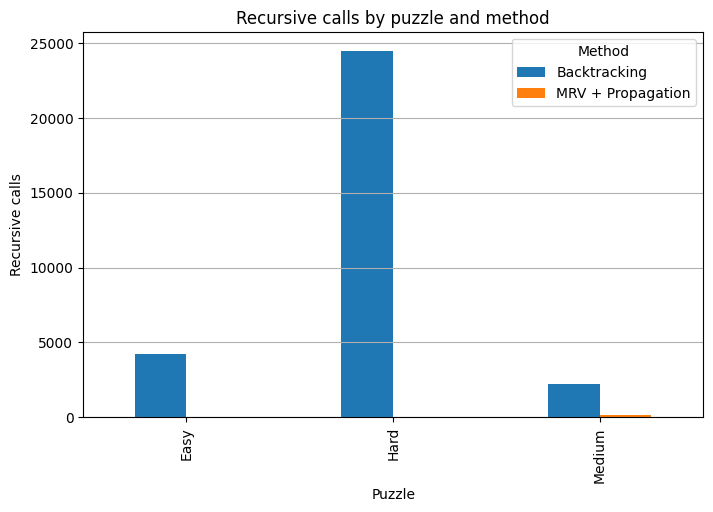

In [12]:
pivot_calls = results_df.pivot(index="Puzzle", columns="Method", values="Recursive_calls")
pivot_calls.plot(kind="bar")
plt.title("Recursive calls by puzzle and method")
plt.ylabel("Recursive calls")
plt.grid(True, axis="y")
plt.show()

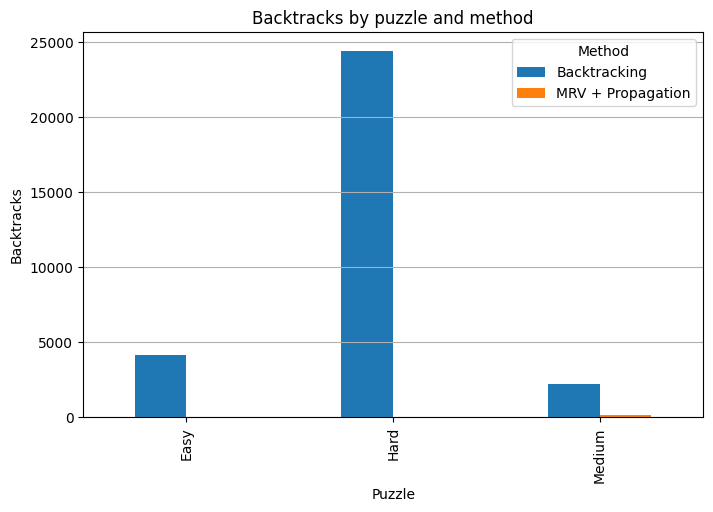

In [13]:
pivot_backtracks = results_df.pivot(index="Puzzle", columns="Method", values="Backtracks")
pivot_backtracks.plot(kind="bar")
plt.title("Backtracks by puzzle and method")
plt.ylabel("Backtracks")
plt.grid(True, axis="y")
plt.show()

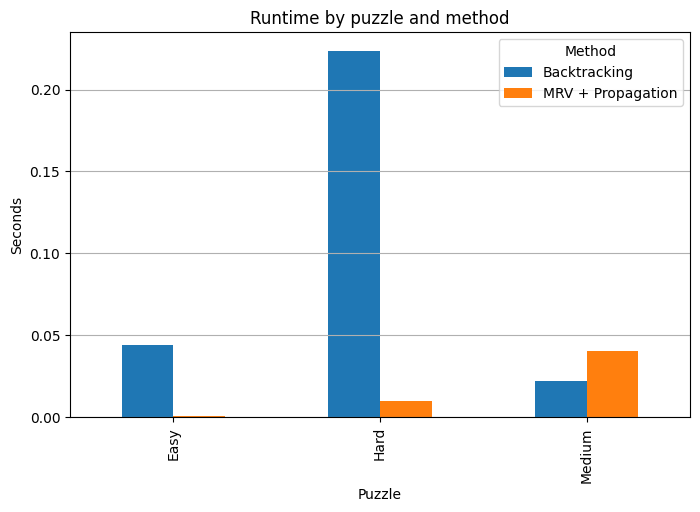

In [14]:
pivot_runtime = results_df.pivot(index="Puzzle", columns="Method", values="Runtime_sec")
pivot_runtime.plot(kind="bar")
plt.title("Runtime by puzzle and method")
plt.ylabel("Seconds")
plt.grid(True, axis="y")
plt.show()

### Interpretation of results

The experiments show a consistent pattern:

- The naive backtracking solver is correct, but its search effort grows quickly with puzzle difficulty.
- The MRV + propagation solver reduces the number of recursive calls and backtracks, especially on more constrained instances.
- Constraint propagation performs useful deterministic work before branching, which makes the search tree smaller.

What surprised me most was how large the difference became on the Hard puzzle. I expected MRV to be better, but seeing the actual numbers — the backtracking solver making dramatically more recursive calls than MRV — really showed me that choosing the right variable to branch on is not just a small optimisation, it fundamentally changes how much work the algorithm does.

This confirms the mathematical intuition that **better variable selection and domain reduction improve efficiency**.

## 12. Solved Puzzle Examples

In [15]:
for puzzle_name in PUZZLES:
    solved_grid = results_df[(results_df["Puzzle"] == puzzle_name) & (results_df["Method"] == "MRV + Propagation")]["Solved_grid"].iloc[0]
    print(f"\nSolved {puzzle_name} puzzle:")
    print_grid(solved_grid)


Solved Easy puzzle:
5 3 4 | 6 7 8 | 9 1 2
6 7 2 | 1 9 5 | 3 4 8
1 9 8 | 3 4 2 | 5 6 7
---------------------
8 5 9 | 7 6 1 | 4 2 3
4 2 6 | 8 5 3 | 7 9 1
7 1 3 | 9 2 4 | 8 5 6
---------------------
9 6 1 | 5 3 7 | 2 8 4
2 8 7 | 4 1 9 | 6 3 5
3 4 5 | 2 8 6 | 1 7 9

Solved Medium puzzle:
1 2 3 | 6 7 8 | 9 4 5
5 8 4 | 2 3 9 | 7 6 1
9 6 7 | 1 4 5 | 3 2 8
---------------------
3 7 2 | 4 6 1 | 5 8 9
6 9 1 | 5 8 3 | 2 7 4
4 5 8 | 7 9 2 | 6 1 3
---------------------
8 3 6 | 9 2 4 | 1 5 7
2 1 9 | 8 5 7 | 4 3 6
7 4 5 | 3 1 6 | 8 9 2

Solved Hard puzzle:
4 6 3 | 8 7 9 | 5 1 2
7 8 2 | 1 3 5 | 6 9 4
5 9 1 | 4 2 6 | 3 7 8
---------------------
8 2 6 | 5 9 1 | 4 3 7
3 1 4 | 6 8 7 | 2 5 9
9 5 7 | 3 4 2 | 1 8 6
---------------------
2 7 5 | 9 1 4 | 8 6 3
1 4 8 | 7 6 3 | 9 2 5
6 3 9 | 2 5 8 | 7 4 1


## 13. Complexity Discussion

In the worst case, naive Sudoku solving by search is exponential in the number of empty cells.  
This is because each empty position may branch into several possibilities.

Backtracking improves over brute force by rejecting invalid assignments early, but it can still be computationally expensive.

Heuristics and propagation improve practical complexity by:
- reducing the number of branches,
- detecting contradictions earlier,
- selecting the most constrained variables first.

Therefore, the project illustrates an important principle of algorithm design:

> **Mathematical structure can transform an intractable search into a manageable one.**

## 14. Comparison with Alternative Approaches

Other Sudoku-solving approaches include:
- exact cover formulations with Algorithm X / Dancing Links,
- SAT solver formulations,
- integer programming models,
- human-style logical rule systems.

Advantages of the current project approach:
- easy to understand,
- implemented from scratch,
- mathematically interpretable,
- well suited for educational analysis.

Disadvantages:
- not the most advanced or fastest possible method,
- limited compared to industrial SAT/CSP solvers,
- propagation rules are intentionally simple.

## 15. Limitations

This project has several limitations:

1. Only three Sudoku puzzles are tested — one per difficulty level. A larger benchmark set would give more reliable conclusions.
2. The constraint propagation is intentionally simple: it only fills cells with exactly one candidate. More advanced rules (e.g. hidden singles, naked pairs) are not implemented.
3. Runtime measurements were taken on an Intel Core i7-1255U (12th Gen, 10 cores, 1700 MHz base clock) with 16 GB RAM running Windows x64. Results may differ on other machines.
4. The project prioritises educational clarity over maximum performance, so no optimisations such as bitmasking or pre-compiled lookups were used.

These limitations are acceptable for a final course project, but they also suggest natural directions for extension.